DATASET CONSTRUCTION

In [84]:
import os
import glob
import numpy as np
import cv2
import rasterio
from sklearn.model_selection import train_test_split

# Directorios principales
landsat_img_dir = "/workspace/RISP/dataCV/scripts/landsat_img"
sentinel_img_dir = "/workspace/RISP/dataCV/scripts/sentinel_img"
masks_dir = "/workspace/RISP/dataCV/scripts/masks"
stations = ["initial", "refresh", "finalize"]
output_dir = "/workspace/RISP/dataCV/scripts/training_data"

# Directorios específicos para Landsat y Sentinel
output_landsat_dir = os.path.join(output_dir, "landsat")
output_sentinel_dir = os.path.join(output_dir, "sentinel")
os.makedirs(output_landsat_dir, exist_ok=True)
os.makedirs(output_sentinel_dir, exist_ok=True)

# Función para agrupar bandas Sentinel por polígono
def group_sentinel_bands(image_station_dir):
    band_files = glob.glob(os.path.join(image_station_dir, "*.tif"))
    polygons = {}

    for band_file in band_files:
        base_name = os.path.basename(band_file)
        polygon_id = "_".join(base_name.split("_")[:2])  # Identificar polígono por las dos primeras partes
        if polygon_id not in polygons:
            polygons[polygon_id] = {"B2": None, "B4": None, "B8": None}
        if "_B2" in base_name:
            polygons[polygon_id]["B2"] = band_file
        elif "_B4" in base_name:
            polygons[polygon_id]["B4"] = band_file
        elif "_B8" in base_name:
            polygons[polygon_id]["B8"] = band_file

    return polygons

# Función para cargar y combinar las bandas Sentinel
def load_and_combine_sentinel_bands(band_files, target_size=(256, 256)):
    required_bands = ["B2", "B4", "B8"]
    for band in required_bands:
        if band_files[band] is None:
            raise ValueError(f"Falta la banda {band} en {band_files}")

    combined = []
    for band in required_bands:
        with rasterio.open(band_files[band]) as src:
            band_data = src.read(1)
            resized_band = cv2.resize(band_data, target_size, interpolation=cv2.INTER_LINEAR)
            combined.append(resized_band)

    return np.stack(combined, axis=0)  # Dimensiones: (3, target_size[0], target_size[1])

# Función para crear datasets
def create_dataset(sensor, img_dir, mask_dir, stations, target_size=(256, 256)):
    images = []
    masks = []
    print(f"Iniciando creación del dataset para {sensor}...")

    for station in stations:
        image_station_dir = os.path.join(img_dir, station)
        mask_station_dir = os.path.join(mask_dir, sensor, station)

        if not os.path.exists(image_station_dir) or not os.path.exists(mask_station_dir):
            print(f"Rutas inexistentes: {image_station_dir} o {mask_station_dir}")
            continue

        if sensor == "sentinel":
            polygons = group_sentinel_bands(image_station_dir)
            for polygon_id, band_files in polygons.items():
                try:
                    img_data = load_and_combine_sentinel_bands(band_files, target_size)

                    mask_file = os.path.join(mask_station_dir, f"{polygon_id}_mask.tif")
                    if not os.path.exists(mask_file):
                        print(f"Mascara no encontrada: {mask_file}")
                        continue

                    with rasterio.open(mask_file) as src_mask:
                        mask_data = src_mask.read(1)
                        mask_resized = cv2.resize(mask_data, target_size, interpolation=cv2.INTER_NEAREST)

                    images.append(img_data)
                    masks.append(mask_resized)

                except Exception as e:
                    print(f"Error procesando {polygon_id}: {e}")

        elif sensor == "landsat":
            image_files = sorted(glob.glob(os.path.join(image_station_dir, "*.tif")))
            mask_files = sorted(glob.glob(os.path.join(mask_station_dir, "*.tif")))

            for img_file, mask_file in zip(image_files, mask_files):
                try:
                    with rasterio.open(img_file) as src_img:
                        img_data = src_img.read()
                        img_resized = np.stack([
                            cv2.resize(band, target_size, interpolation=cv2.INTER_LINEAR) for band in img_data
                        ])

                    with rasterio.open(mask_file) as src_mask:
                        mask_data = src_mask.read(1)
                        mask_resized = cv2.resize(mask_data, target_size, interpolation=cv2.INTER_NEAREST)

                    images.append(img_resized)
                    masks.append(mask_resized)

                except Exception as e:
                    print(f"Error procesando {img_file} o {mask_file}: {e}")

    return np.array(images), np.array(masks)

# Crear datasets para Landsat y Sentinel
X_train_landsat, Y_train_landsat = create_dataset("landsat", landsat_img_dir, masks_dir, stations)
X_train_sentinel, Y_train_sentinel = create_dataset("sentinel", sentinel_img_dir, masks_dir, stations)

# Guardar datasets
np.save(os.path.join(output_landsat_dir, "X_train_landsat.npy"), X_train_landsat)
np.save(os.path.join(output_landsat_dir, "Y_train_landsat.npy"), Y_train_landsat)
np.save(os.path.join(output_sentinel_dir, "X_train_sentinel.npy"), X_train_sentinel)
np.save(os.path.join(output_sentinel_dir, "Y_train_sentinel.npy"), Y_train_sentinel)

print("Datasets generados y guardados.")


Iniciando creación del dataset para landsat...


Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

Iniciando creación del dataset para sentinel...
Datasets generados y guardados.


Test Imagenes

Imagen: /workspace/RISP/dataCV/scripts/training_data/images/landsat_finalize_Polygon_1_landsat8.npy
Máscara: /workspace/RISP/dataCV/scripts/training_data/masks/landsat_finalize_Polygon_1_landsat8_mask.npy
Dimensiones de la imagen: (21, 256, 256)
Dimensiones de la máscara: (256, 256)


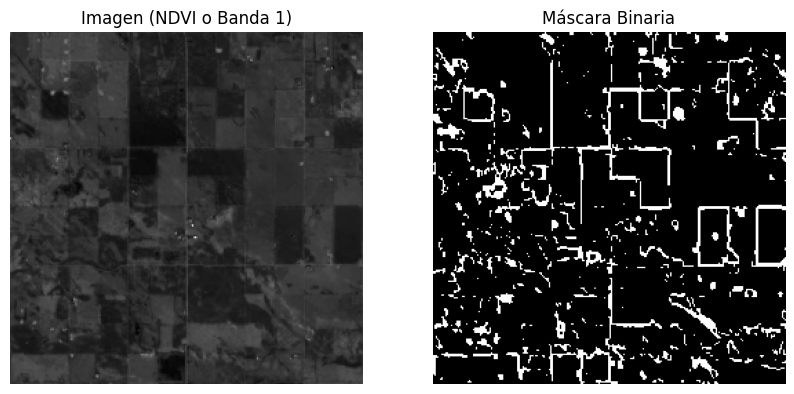

Imagen: /workspace/RISP/dataCV/scripts/training_data/images/landsat_finalize_Polygon_2_landsat8.npy
Máscara: /workspace/RISP/dataCV/scripts/training_data/masks/landsat_finalize_Polygon_2_landsat8_mask.npy
Dimensiones de la imagen: (21, 256, 256)
Dimensiones de la máscara: (256, 256)


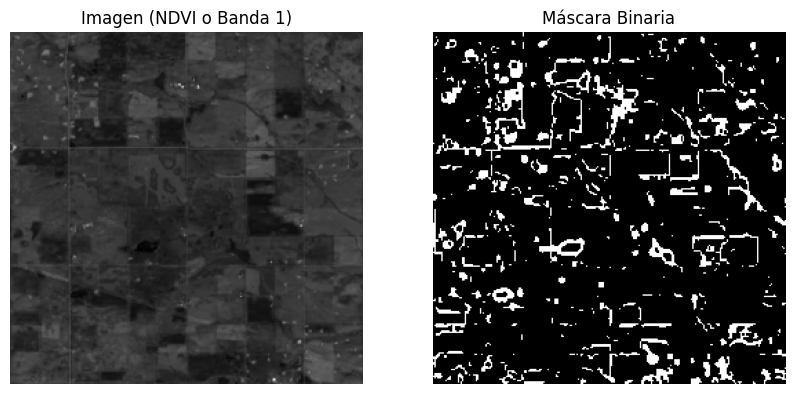

Imagen: /workspace/RISP/dataCV/scripts/training_data/images/landsat_finalize_Polygon_3_landsat8.npy
Máscara: /workspace/RISP/dataCV/scripts/training_data/masks/landsat_finalize_Polygon_3_landsat8_mask.npy
Dimensiones de la imagen: (21, 256, 256)
Dimensiones de la máscara: (256, 256)


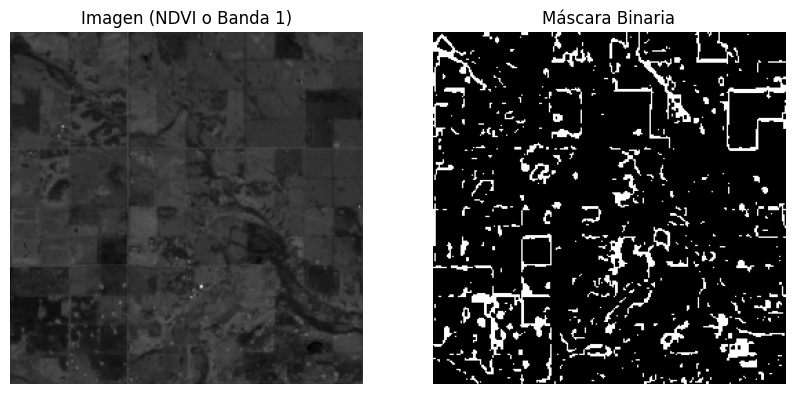

In [78]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Directorios
images_dir = "/workspace/RISP/dataCV/scripts/training_data/images"
masks_dir = "/workspace/RISP/dataCV/scripts/training_data/masks"

# Listar los archivos generados
image_files = sorted(os.listdir(images_dir))
mask_files = sorted(os.listdir(masks_dir))

# Asegurarse de que haya correspondencia entre imágenes y máscaras
assert len(image_files) == len(mask_files), "El número de imágenes y máscaras no coincide."

# Visualizar ejemplos
def visualize_example(image_path, mask_path, bands_to_display=None):
    """
    Visualiza una imagen y su máscara correspondiente.
    
    Args:
    - image_path (str): Ruta del archivo .npy de la imagen.
    - mask_path (str): Ruta del archivo .npy de la máscara.
    - bands_to_display (list or None): Índices de las bandas a mostrar.
                                       Si None, se seleccionan las primeras tres bandas.
    """
    # Cargar la imagen y la máscara
    image = np.load(image_path)
    mask = np.load(mask_path)

    print(f"Imagen: {image_path}")
    print(f"Máscara: {mask_path}")
    print(f"Dimensiones de la imagen: {image.shape}")
    print(f"Dimensiones de la máscara: {mask.shape}")

    # Graficar la imagen y la máscara
    plt.figure(figsize=(10, 5))

    # Mostrar la imagen (si tiene múltiples bandas, mostrar la primera banda)
    plt.subplot(1, 2, 1)
    plt.imshow(image[0], cmap='gray')
    plt.title("Imagen (NDVI o Banda 1)")
    plt.axis("off")

    # Mostrar la máscara
    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title("Máscara Binaria")
    plt.axis("off")

    plt.show()

# Probar con los primeros 5 archivos
for i in range(3):
    image_path = os.path.join(images_dir, image_files[i])
    mask_path = os.path.join(masks_dir, mask_files[i])
    visualize_example(image_path, mask_path, bands_to_display=[0, 3, 8])  # Ejemplo: Blue (B2), Red (B4), NIR (B8)


Prueba de Imagen y transposicion

Verificando correspondencia entre imágenes y máscaras...
Imagen: /workspace/RISP/dataCV/scripts/training_data/images/landsat_finalize_Polygon_1_landsat8.npy
Máscara: /workspace/RISP/dataCV/scripts/training_data/masks/landsat_finalize_Polygon_1_landsat8_mask.npy
Dimensiones de la imagen: (21, 256, 256)
Dimensiones de la máscara: (256, 256)


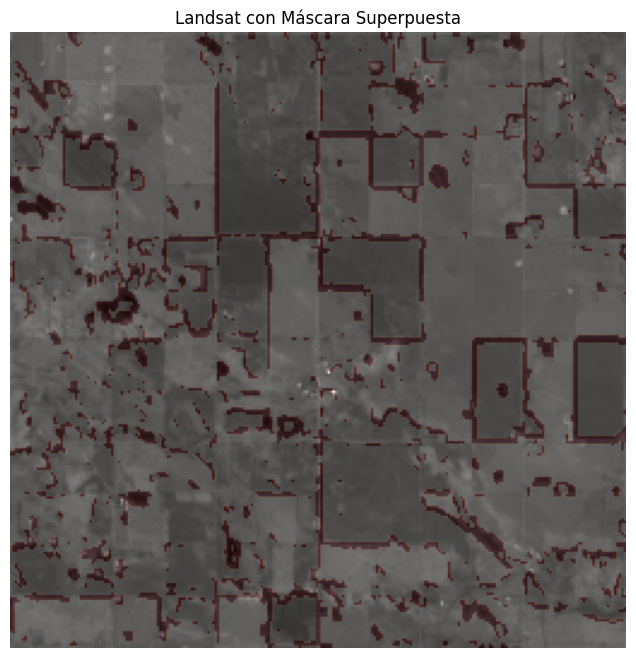

Imagen: /workspace/RISP/dataCV/scripts/training_data/images/sentinel_finalize_Polygon_1.npy
Máscara: /workspace/RISP/dataCV/scripts/training_data/masks/sentinel_finalize_Polygon_1_mask.npy
Dimensiones de la imagen: (3, 256, 256)
Dimensiones de la máscara: (256, 256)


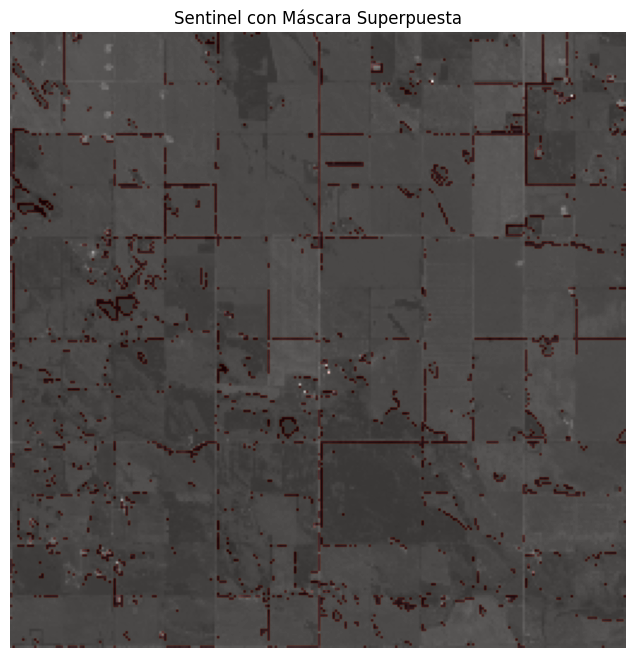

In [82]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Directorios
images_dir = "/workspace/RISP/dataCV/scripts/training_data/images"
masks_dir = "/workspace/RISP/dataCV/scripts/training_data/masks"

# Listar los archivos generados
image_files = sorted(os.listdir(images_dir))
mask_files = sorted(os.listdir(masks_dir))

# Verificar correspondencia entre imágenes y máscaras
print("Verificando correspondencia entre imágenes y máscaras...")

# Ajustar sufijos de máscaras
adjusted_mask_files = []
for image_file in image_files:
    base_name = image_file.replace(".npy", "")  # Eliminar la extensión de la imagen
    potential_mask = f"{base_name}_mask.npy"
    found_mask = None

    # Buscar la máscara correspondiente
    for mask_file in mask_files:
        if mask_file.startswith(base_name) and mask_file.endswith("_mask.npy"):
            found_mask = mask_file
            break
        elif mask_file.startswith(base_name) and mask_file.endswith("_mask.npy"):
            found_mask = mask_file
            break

    if found_mask:
        adjusted_mask_files.append(found_mask)
    else:
        print(f"Advertencia: No se encontró una máscara para la imagen {image_file}")

# Visualizar superposición de una imagen y su máscara
def visualize_superposed(image_path, mask_path, title):
    """
    Visualiza una imagen con su máscara superpuesta.
    
    Args:
    - image_path (str): Ruta del archivo .npy de la imagen.
    - mask_path (str): Ruta del archivo .npy de la máscara.
    - title (str): Título para la visualización.
    """
    # Cargar imagen y máscara
    image = np.load(image_path)
    mask = np.load(mask_path)

    print(f"Imagen: {image_path}")
    print(f"Máscara: {mask_path}")
    print(f"Dimensiones de la imagen: {image.shape}")
    print(f"Dimensiones de la máscara: {mask.shape}")

    # Graficar
    plt.figure(figsize=(8, 8))
    plt.imshow(image[0], cmap='gray')  # Escala de grises
    plt.imshow(mask, cmap='Reds', alpha=0.2)  # Superponer la máscara en rojo
    plt.title(title)
    plt.axis("off")
    plt.show()

# Mostrar una imagen y máscara de Landsat
landsat_image_file = next(f for f in image_files if "landsat" in f)
landsat_mask_file = next(f for f in adjusted_mask_files if "landsat" in f)

landsat_image_path = os.path.join(images_dir, landsat_image_file)
landsat_mask_path = os.path.join(masks_dir, landsat_mask_file)

visualize_superposed(landsat_image_path, landsat_mask_path, "Landsat con Máscara Superpuesta")

# Mostrar una imagen y máscara de Sentinel
sentinel_image_file = next(f for f in image_files if "sentinel" in f)
sentinel_mask_file = next(f for f in adjusted_mask_files if "sentinel" in f)

sentinel_image_path = os.path.join(images_dir, sentinel_image_file)
sentinel_mask_path = os.path.join(masks_dir, sentinel_mask_file)

visualize_superposed(sentinel_image_path, sentinel_mask_path, "Sentinel con Máscara Superpuesta")


Filtrado del Dataset

In [83]:
import numpy as np

# Rutas de archivos
X_train_path = "/workspace/RISP/dataCV/scripts/training_data/X_train.npy"
Y_train_path = "/workspace/RISP/dataCV/scripts/training_data/Y_train.npy"
X_val_path = "/workspace/RISP/dataCV/scripts/training_data/X_val.npy"
Y_val_path = "/workspace/RISP/dataCV/scripts/training_data/Y_val.npy"

# Cargar los datos
X_train = np.load(X_train_path, allow_pickle=True)
Y_train = np.load(Y_train_path, allow_pickle=True)
X_val = np.load(X_val_path, allow_pickle=True)
Y_val = np.load(Y_val_path, allow_pickle=True)

# Filtrar solo los datos Landsat (por el nombre del archivo)
landsat_train_indices = [i for i, x in enumerate(X_train) if 'landsat' in x]
landsat_val_indices = [i for i, x in enumerate(X_val) if 'landsat' in x]

X_train_landsat = np.array([X_train[i] for i in landsat_train_indices])
Y_train_landsat = np.array([Y_train[i] for i in landsat_train_indices])
X_val_landsat = np.array([X_val[i] for i in landsat_val_indices])
Y_val_landsat = np.array([Y_val[i] for i in landsat_val_indices])

# Guardar los datos filtrados
np.save("/workspace/RISP/dataCV/scripts/training_data/X_train_landsat.npy", X_train_landsat)
np.save("/workspace/RISP/dataCV/scripts/training_data/Y_train_landsat.npy", Y_train_landsat)
np.save("/workspace/RISP/dataCV/scripts/training_data/X_val_landsat.npy", X_val_landsat)
np.save("/workspace/RISP/dataCV/scripts/training_data/Y_val_landsat.npy", Y_val_landsat)

print("Dataset filtrado solo con Landsat creado.")



Dataset filtrado solo con Landsat creado.


/tmp/ipykernel_25185/3872248153.py:16: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  landsat_train_indices = [i for i, x in enumerate(X_train) if 'landsat' in x]
/tmp/ipykernel_25185/3872248153.py:17: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  landsat_val_indices = [i for i, x in enumerate(X_val) if 'landsat' in x]
